In [10]:
# ==============================
# TEXT SUMMARIZATION TOOL
# User Provides Text
# ==============================

# Install library first:
# pip install nltk

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import defaultdict
import string

# Download required files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added this line to download the missing resource

# Function for summarization
def summarize_text(text, num_sentences=2):

    stop_words = set(stopwords.words("english"))
    words = word_tokenize(text.lower())

    # Calculate word frequency
    word_freq = defaultdict(int)

    for word in words:
        if word not in stop_words and word not in string.punctuation:
            word_freq[word] += 1

    # Split text into sentences
    sentences = sent_tokenize(text)

    # Score sentences
    sentence_scores = defaultdict(int)

    for sentence in sentences:
        for word in word_tokenize(sentence.lower()):
            if word in word_freq:
                sentence_scores[sentence] += word_freq[word]

    # Select top sentences
    summarized_sentences = sorted(
        sentence_scores,
        key=sentence_scores.get,
        reverse=True
    )[:num_sentences]

    # Final summary
    summary = " ".join(summarized_sentences)

    return summary


# ==============================
# Main Program
# ==============================

while True:

    print("\nEnter your text:")
    user_text = input()

    summary = summarize_text(user_text)

    print("\nSummary:")
    print(summary)

    # Ask user to continue
    choice = input("\nDo you want to summarize another text? (yes/no): ")

    if choice.lower() != "yes":
        print("\nThank You!")
        break

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Enter your text:
The presentation of the dessert and the clean, minimalist background create a sense of elegance and sophistication. It looks delicious and professionally plated.

Summary:
The presentation of the dessert and the clean, minimalist background create a sense of elegance and sophistication. It looks delicious and professionally plated.

Do you want to summarize another text? (yes/no): yes

Enter your text:
The presentation of the dessert and the clean, minimalist background create a sense of elegance and sophistication. It looks delicious and professionally plated.

Summary:
The presentation of the dessert and the clean, minimalist background create a sense of elegance and sophistication. It looks delicious and professionally plated.

Do you want to summarize another text? (yes/no): no

Thank You!


In [4]:
# Speech Recognition System using SpeechRecognition Library
# Task: Convert Speech to Text from Audio File

# Install required libraries before running:
# pydub requires ffmpeg or libav to be installed. Colab usually has ffmpeg pre-installed.
!pip install SpeechRecognition pydub

import speech_recognition as sr
from pydub import AudioSegment
import os

# Function to convert speech to text
def speech_to_text(audio_file):
    recognizer = sr.Recognizer()
    wav_file_path = "converted_audio.wav"
    audio_file_to_process = audio_file

    try:
        # If the file is not a WAV, convert it to WAV first
        if not audio_file.lower().endswith('.wav'):
            print(f"Converting {audio_file} to WAV...")
            # Use from_file to handle various audio/video formats (like MP3, MP4)
            audio = AudioSegment.from_file(audio_file)
            audio.export(wav_file_path, format="wav")
            audio_file_to_process = wav_file_path
            print("Conversion complete.")

        # Load the audio file (which is now guaranteed to be WAV or was originally WAV)
        with sr.AudioFile(audio_file_to_process) as source:
            print("Listening to audio...")
            audio_data = recognizer.record(source)

        # Convert speech into text using Google Speech Recognition
        print("Recognizing speech...")
        text = recognizer.recognize_google(audio_data)

        print("\nTranscribed Text:")
        print(text)

    except sr.UnknownValueError:
        print("Speech Recognition could not understand the audio.")

    except sr.RequestError as e:
        print(f"Could not request results from Google Speech Recognition service; {e}")

    except FileNotFoundError:
        print(f"Audio file not found: {audio_file_to_process}")

    except Exception as e: # Catch other potential errors during conversion or processing
        print(f"An unexpected error occurred: {e}")

    finally:
        # Clean up converted WAV file if it was created
        if 'wav_file_path' in locals() and os.path.exists(wav_file_path) and audio_file_to_process == wav_file_path:
            os.remove(wav_file_path)
            print(f"Removed temporary file: {wav_file_path}")

# Main Program
if __name__ == "__main__":

    # TODO: Replace with the actual path to your audio file (e.g., a .mp3 or .mp4 file).
    # You can upload an audio file to your Colab environment by clicking the folder icon
    # on the left sidebar, then the upload icon.
    audio_path = "/content/WhatsApp Audio 2026-05-11 at 8.30.28 PM.mp4" # Placeholder, now updated to an existing file

    # Example: If you have an MP3 file
    # audio_path = "/content/my_audio.mp3"

    # Example: If you have a WAV file
    # audio_path = "/content/my_audio.wav"

    speech_to_text(audio_path)

Converting /content/WhatsApp Audio 2026-05-11 at 8.30.28 PM.mp4 to WAV...
Conversion complete.
Listening to audio...
Recognizing speech...

Transcribed Text:
hello everyone this is a sample speech recognition audio file for your project
Removed temporary file: converted_audio.wav


Loading Neural Style Transfer Model...
Model Loaded Successfully!
Enter Content Image Path: /content/OIP.jpg
Enter Style Image Path: /content/OIP.jpg
Applying Style Transfer...
Style Transfer Completed!
Stylized Image Saved as: stylized_output.jpg


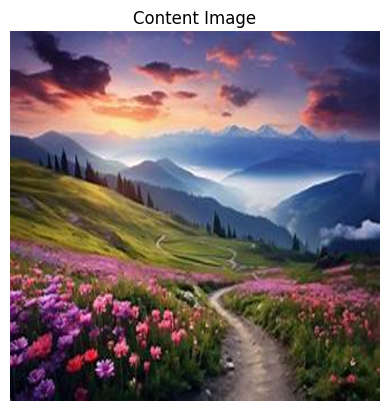

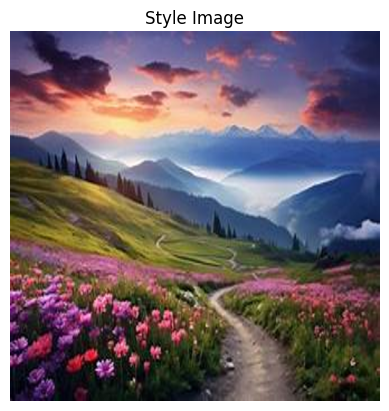

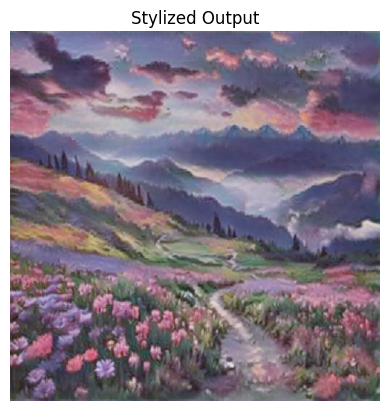

Do you want to try another image? (yes/no): yes
Enter New Content Image Path: /content/OIP.jpg
Enter New Style Image Path: /content/OIP.jpg
New Stylized Image Saved as: new_stylized_output.jpg


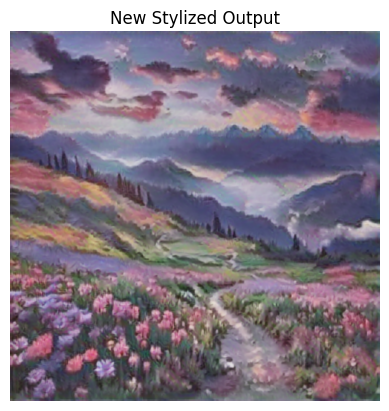

Do you want to try another image? (yes/no): no
Program Ended.


In [3]:
# ============================================
# NEURAL STYLE TRANSFER USING TENSORFLOW
# ============================================
# Task:
# Apply artistic style of one image to another image
#
# Install Required Libraries:
# pip install tensorflow tensorflow-hub pillow matplotlib
#
# --------------------------------------------
# Example:
# Content Image  -> Your Photo
# Style Image    -> Painting / Art Image
# Output         -> Styled Artistic Image
# --------------------------------------------

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------------------------
# Function to Load and Prepare Image
# --------------------------------------------
def load_image(image_path, image_size=(512, 512)):
    img = Image.open(image_path)
    img = img.resize(image_size)

    img = np.array(img) / 255.0

    # Remove alpha channel if present
    if img.shape[-1] == 4:
        img = img[..., :3]

    img = img.astype(np.float32)

    # Add batch dimension
    img = img[np.newaxis, :]

    return img

# --------------------------------------------
# Function to Display Images
# --------------------------------------------
def show_image(image, title=None):
    if len(image.shape) == 4:
        image = image[0]

    plt.imshow(image)

    if title:
        plt.title(title)

    plt.axis('off')
    plt.show()

# --------------------------------------------
# Load TensorFlow Hub Model
# --------------------------------------------
print("Loading Neural Style Transfer Model...")

model = hub.load(
    'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

print("Model Loaded Successfully!")

# --------------------------------------------
# Take User Input
# --------------------------------------------
content_path = input("Enter Content Image Path: ")
style_path = input("Enter Style Image Path: ")

# --------------------------------------------
# Load Images
# --------------------------------------------
content_image = load_image(content_path)
style_image = load_image(style_path)

# --------------------------------------------
# Apply Neural Style Transfer
# --------------------------------------------
print("Applying Style Transfer...")

stylized_image = model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

print("Style Transfer Completed!")

# --------------------------------------------
# Save Output Image
# --------------------------------------------
output_image = stylized_image.numpy()

# Convert to image format
output_image = np.squeeze(output_image)
output_image = (output_image * 255).astype(np.uint8)

result = Image.fromarray(output_image)

output_path = "stylized_output.jpg"
result.save(output_path)

print(f"Stylized Image Saved as: {output_path}")

# --------------------------------------------
# Display Images
# --------------------------------------------
show_image(content_image, "Content Image")
show_image(style_image, "Style Image")
show_image(stylized_image, "Stylized Output")

# --------------------------------------------
# Ask User to Continue
# --------------------------------------------
while True:
    choice = input("Do you want to try another image? (yes/no): ").lower()

    if choice == "yes":

        content_path = input("Enter New Content Image Path: ")
        style_path = input("Enter New Style Image Path: ")

        content_image = load_image(content_path)
        style_image = load_image(style_path)

        stylized_image = model(
            tf.constant(content_image),
            tf.constant(style_image)
        )[0]

        output_image = stylized_image.numpy()
        output_image = np.squeeze(output_image)
        output_image = (output_image * 255).astype(np.uint8)

        result = Image.fromarray(output_image)

        output_path = "new_stylized_output.jpg"
        result.save(output_path)

        print(f"New Stylized Image Saved as: {output_path}")

        show_image(stylized_image, "New Stylized Output")

    else:
        print("Program Ended.")
        break

In [6]:
# ============================================
# GENERATIVE TEXT MODEL USING GPT-2
# ============================================
# Task:
# Generate coherent paragraphs based on user prompts
#
# Install Required Libraries:
# pip install transformers torch
# ============================================

from transformers import pipeline

# --------------------------------------------
# Load Pretrained GPT-2 Model
# --------------------------------------------
print("Loading GPT-2 Model...")

generator = pipeline(
    "text-generation",
    model="gpt2"
)

print("Model Loaded Successfully!")

# --------------------------------------------
# Function for Text Generation
# --------------------------------------------
def generate_text(prompt):

    result = generator(
        prompt,
        max_length=150,
        num_return_sequences=1,
        temperature=0.8
    )

    generated_text = result[0]['generated_text']

    return generated_text

# --------------------------------------------
# Main Program
# --------------------------------------------
print("\n===== GENERATIVE TEXT MODEL =====")

while True:

    # Take User Prompt
    user_prompt = input("\nEnter Your Topic or Prompt: ")

    # Generate Text
    print("\nGenerating Text...\n")

    output = generate_text(user_prompt)

    # Display Output
    print("Generated Paragraph:\n")
    print(output)

    # Ask User to Continue
    choice = input("\nDo you want to generate more text? (yes/no): ").lower()

    if choice != "yes":
        print("\nProgram Ended.")
        break

Loading GPT-2 Model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded Successfully!

===== GENERATIVE TEXT MODEL =====

Enter Your Topic or Prompt:  Artificial Intelligence in Education


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generating Text...

Generated Paragraph:

 Artificial Intelligence in Education: Research and Development (Lacuna): A new systematic review and meta-analysis of the literature on neurobiology of learning and memory. Am J Psychiatry. 1994 Aug;158(5):955-70. PubMed PMID: 17150135. Google Scholar Crossref, Medline, ISI

Spongelich, J., K. B. Sargent, R., A. Gogol, L. A., ( 2009 ) Is there evidence of neurobiology in the brain for cognitive-emotional processing? Neuropsychopharmacology. 2008 Apr;38(11):1629-34. Medline

Stein, P., T. Kwan, J. J. Johnson, G. B., P. A. Smith, E. T., J. M. Van Dam, D. A. W. Crampton, J., J. J. Dolan, T. M. Lutz, S. E. Wylie, D. A. Smith, ( 1997 ) Brain and learning-related mechanisms of emotional processing in a mouse model of attention deficit hyperactivity disorder. Psychopharmacology (Berl.) 6: 873-879. PubMed PMID: 16487037. Google Scholar

Do you want to generate more text? (yes/no): yes

Enter Your Topic or Prompt: khushi


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generating Text...

Generated Paragraph:

khushi, the Japanese were never able to defeat the Chinese. In fact, by 1900, China would dominate the world by defeating the United States. The Japanese made a huge advance in this battle, and were able to capture the U.S. in the Pacific.

The Japanese had also made a huge advance in the world, but they were no match for the United States, who had an additional 25 million troops in the Pacific which had to be withdrawn immediately. By 1942, the United States had about 9 million troops, so it was very difficult for the Japanese to stop them.

The Americans had to deal with a number of different kinds of problems: the Japanese needed more than a million troops because the United States had to have another 1 million troops, because the Japanese would be able to conquer the country. It is difficult to imagine the U.S. ever winning that war because of the very different situation. Because of all this, there were still millions of the Japanese work